In [11]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

import warnings
warnings.simplefilter('ignore')

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [3]:
# Load California housing data into sklearn Bunch object
housing = fetch_california_housing(as_frame=True)

# Convert to pandas DataFrame
df = housing.frame

# View the first 5 rows
df.shape
df.head()
df.info()

(20640, 9)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# Check for missing data in each column
df.isnull().sum().sort_values(ascending=False)

# Quick summary of data types and non-null counts
df.info()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X.shape, y.shape

((20640, 8), (20640,))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
    , random_state=27
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

In [8]:
# Standardize features using StandardScaler
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data with same scaler
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled, X_test_scaled

(array([[-8.51025499e-01, -1.47780678e+00,  6.30138960e-04, ...,
          3.14325052e-03,  1.62092613e+00, -1.37763087e+00],
        [-2.05591029e-01,  5.85876404e-01, -1.91237767e-01, ...,
         -8.48674842e-02,  1.39185223e+00, -9.18625845e-01],
        [ 1.77235049e-01,  1.06211099e+00, -5.11011129e-02, ...,
         -5.97145089e-02,  9.38379419e-01, -1.42752272e+00],
        ...,
        [-3.98843063e-01, -8.42827342e-01, -3.57921951e-01, ...,
         -5.49053686e-02, -6.74487812e-01,  5.08281085e-01],
        [ 7.23598290e-02,  1.09641822e-01,  1.67414906e-01, ...,
         -5.05071289e-02, -5.48263420e-01,  1.54048945e-01],
        [-9.42765045e-01,  8.23993694e-01, -5.69918873e-01, ...,
          8.81234269e-02, -7.77337316e-01,  6.47978267e-01]]),
 array([[-0.72329421,  0.5858764 , -0.74273113, ...,  0.08494605,
         -0.73058754,  0.73279441],
        [-0.52794047, -1.95404137, -0.19792841, ..., -0.07226542,
         -0.32853948, -0.42968571],
        [-0.96541095,  1.

In [13]:
# Instantiate XGBoost regressor with default parameters
base_model = xgb.XGBRegressor(
    random_state=27
#     , verbosity=1
)

# Fit model to scaled training data
base_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
# Predict on test set
y_pred_base = base_model.predict(X_test_scaled)

In [15]:
# Calculate RMSE and R^2 for base model
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

rmse_base, r2_base

(0.4705259290274849, 0.8320893039709102)

In [17]:
rmse_base / y_test.mean()

0.22746597450083783

0.22746556919690575

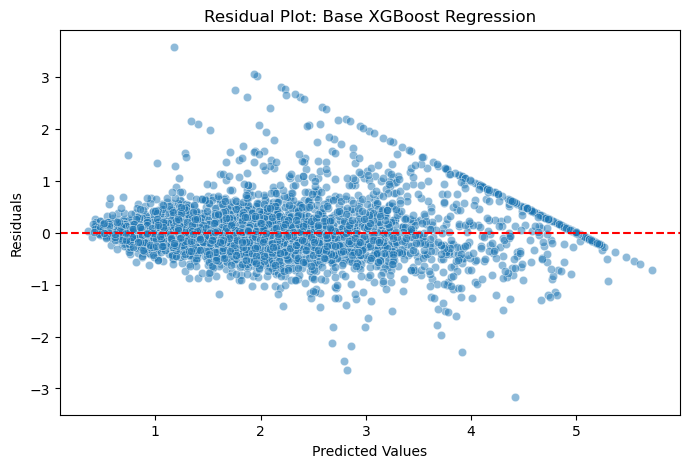

In [18]:
# Plot residuals to check prediction errors
residuals = y_test - y_pred_base

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=y_pred_base
    , y=residuals
    , alpha=0.5
)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot: Base XGBoost Regression')
plt.show();